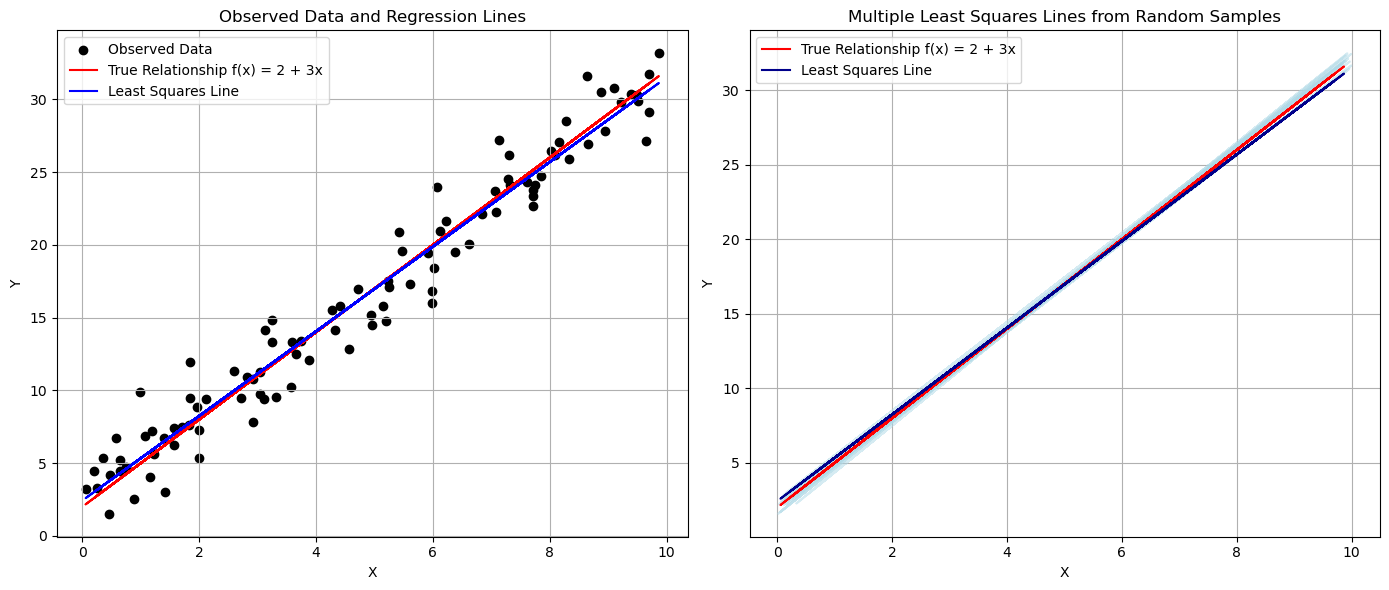

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

def true_relationship(x):
    return 2 + 3*x

n_samples = 100
x = np.random.rand(n_samples) * 10 
y = true_relationship(x) + np.random.normal(0, 2, n_samples)  # 添加噪声

data = pd.DataFrame({'X': x, 'Y': y})

slope, intercept = np.polyfit(data['X'], data['Y'], 1)

plt.figure(figsize=(14, 6))

# 左侧图
plt.subplot(1, 2, 1)
plt.scatter(data['X'], data['Y'], color='black', label='Observed Data')
plt.plot(data['X'], true_relationship(data['X']), color='red', label='True Relationship f(x) = 2 + 3x')
plt.plot(data['X'], slope * data['X'] + intercept, color='blue', label='Least Squares Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Observed Data and Regression Lines')
plt.legend()
plt.grid()

# 右侧图: 多次模拟的最小二乘线
plt.subplot(1, 2, 2)
for _ in range(10):
    x_sample = np.random.rand(n_samples) * 10
    y_sample = true_relationship(x_sample) + np.random.normal(0, 2, n_samples)
    slope_sample, intercept_sample = np.polyfit(x_sample, y_sample, 1)
    plt.plot(x_sample, slope_sample * x_sample + intercept_sample, color='lightblue', alpha=0.5)

plt.plot(data['X'], true_relationship(data['X']), color='red', label='True Relationship f(x) = 2 + 3x')
plt.plot(data['X'], slope * data['X'] + intercept, color='darkblue', label='Least Squares Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Multiple Least Squares Lines from Random Samples')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()